<a href="https://colab.research.google.com/github/Hansini23/Statistical-Learning-e23291/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

A comprehensive Python-based toolkit developed for data sanitization, preprocessing, exploratory data analysis, and interactive visualization within Google Colab environments. The system automates many of the repetitive tasks involved in preparing real-world datasets for analysis and machine learning applications.

The toolkit is implemented using two modular classes: DataInspector and PlottingMethods. Together, these classes provide a complete workflow for data ingestion, cleaning, transformation, visualization, and statistical relationship analysis.

## Features

**Inteligent Data Ingestion**:  
-  Upload CSV datasets directly through Google Colab.
-  Automatically identify and convert common null indicators such as '?', 'N/A', 'NULL', and blank spaces into missing values.
-  Perform automatic data type correction by converting suitable columns into numerical formats.

**Comprehensive Data Inspection**

-  Display dataset dimensions and structural information.
-  Preview dataset contents.
-  Identify numerical and categorical attributes.
-  Generate column-wise summaries and missing value reports.

**Automated Data Cleaning**
-  Handle missing values using:
   -  Mean Imputation
   - Median Imputation
   - Mode Imputation
   - Constant Value Replacement
- Remove duplicate records.
- Detect and optionally remove outliers using the Interquartile Range (IQR) method.
- Support interactive row and column deletion.

**Feature Engineering and Data Preparation**

-  Normalize numerical data using:
   - Min-Max Scaling
   - Standard (Z-Score) Scaling
   - Robust Scaling
- Encode categorical variables using:
  - One-Hot Encoding
  - Ordinal Encoding
  - Uniform Encoding

- Merge transformed numerical and categorical datasets into a unified machine-learning-ready dataset.

** Interactive Visualizations**


*   Generate violin plots, box plots, scatter plots, and histograms for numerical variables.
*   Automatically select suitable visualizations for relationships between variables.


*   Create categorical frequency plots with count and percentage information.
*   Produce interactive Plotly-based visualizations for enhanced data exploration.

**Advanced Statistical Analysis**


*  Pearson Correlation Heatmaps for numerical variables.
*   Cramér’s V Association Heatmaps for categorical variables.


*   Point-Biserial and Eta-based association measures for mixed variable types.
*   Unified Association Heatmap combining numerical and categorical relationships within a single visualization.









In [ ]:
# Install the data-analysis-tool package from GitHub
!pip install -q "git+https://github.com/hansini23/Statistical-Learning-e23291.git"

  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

from data_inspector import DataInspector, PlottingMethods

print('✅ Imports successful')

✅ Imports successful


In [ ]:
inspector = DataInspector()

In [ ]:
# Initialize and Upload
inspector.upload_data()
# Alternatively use
#inspector.df=pd.read_csv('xxxx.csv')

Saving titanic_sample.csv to titanic_sample.csv
✅ Successfully loaded 'titanic_sample.csv' (20 rows, 10 columns).


In [ ]:
# Introduce some synthetic garbage strings to showcase sanitisation
inspector.df.loc[0, 'Age']    = '?'
inspector.df.loc[1, 'Cabin']  = 'NULL'
inspector.df.loc[2, 'Fare']   = 'n/a'

# Re-run sanitisation manually (upload_data() does this automatically)
import numpy as np
_GARBAGE = {'?','n/a','na','null','none','nan',' ','','--','N/A','NULL','None','NaN','NA'}
inspector.df.replace(_GARBAGE, np.nan, inplace=True)
inspector.df = inspector.df.infer_objects()

print(f'Dataset loaded: {inspector.df.shape[0]:,} rows × {inspector.df.shape[1]} columns')
inspector.df.head()

Dataset loaded: 20 rows × 11 columns


/tmp/ipykernel_3703/4043625700.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[0, 'Age']    = '?'
/tmp/ipykernel_3703/4043625700.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NULL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[1, 'Cabin']  = 'NULL'
/tmp/ipykernel_3703/4043625700.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'n/a' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[2, 'Fare']   = 'n/a'
/tmp/ipykernel_3703/4043625700.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated an

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,7.2500,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,512.3292,C,NaN
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,NaN,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,53.1000,S,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,NaN


In [ ]:
# High-level summary: dimensions, numeric/categorical split, first 20 rows
inspector.data_summary()

 STRUCTURAL SUMMARY: 20 Rows | 11 Columns
 Numeric Features (8): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin']
 Categorical Features (3): ['Name', 'Sex', 'Embarked']

📊 FIRST 20 ROWS PREVIEW:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,7.2500,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,512.3292,C,NaN
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,NaN,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,53.1000,S,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,NaN
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,8.4583,Q,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,S,NaN
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,S,NaN
8,9,1,3,"Johnson, Mrs. Oscar W",female,27.0,0,2,11.1333,S,NaN
9,10,1,2,"Nasser, Mrs. Nicholas",female,14.0,1,0,30.0708,C,NaN


In [ ]:
# 4-B  Column-level detail: dtype, nulls, unique counts
import pandas as pd

# Get data types
dtypes = inspector.df.dtypes
# Get null counts
null_counts = inspector.df.isnull().sum()
# Get unique counts
unique_counts = inspector.df.nunique()

# Combine into a DataFrame for display
column_details_df = pd.DataFrame({
    'Dtype': dtypes,
    'Nulls': null_counts,
    'Unique': unique_counts
})

print("Column-level details:")
display(column_details_df)

Column-level details:


,Dtype,Nulls,Unique
PassengerId,int64,0,20
Survived,int64,0,2
Pclass,int64,0,3
Name,object,0,20
Sex,object,0,2
Age,float64,4,13
SibSp,int64,0,4
Parch,int64,0,4
Fare,float64,1,18
Embarked,object,0,3


In [ ]:
import pandas as pd
from IPython.display import display

print("Categorical Value-Count Tables:")

categorical_cols = inspector.df.select_dtypes(include='object').columns

if not categorical_cols.empty:
    for col in categorical_cols:
        print(f"\n--- {col} ---")
        display(inspector.df[col].value_counts().reset_index(name='count'))
else:
    print("No categorical columns found in the DataFrame.")

Categorical Value-Count Tables:

--- Name ---


,Name,count
0,"Braund, Mr. Owen Harris",1
1,"Cumings, Mrs. John Bradley",1
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath",1
4,"Allen, Mr. William Henry",1
5,"Moran, Mr. James",1
6,"McCarthy, Mr. Timothy J",1
7,"Palsson, Master. Gosta Leonard",1
8,"Johnson, Mrs. Oscar W",1
9,"Nasser, Mrs. Nicholas",1



--- Sex ---


,Sex,count
0,female,11
1,male,9



--- Embarked ---


,Embarked,count
0,S,15
1,C,3
2,Q,2


/tmp/ipykernel_3703/3605222663.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')


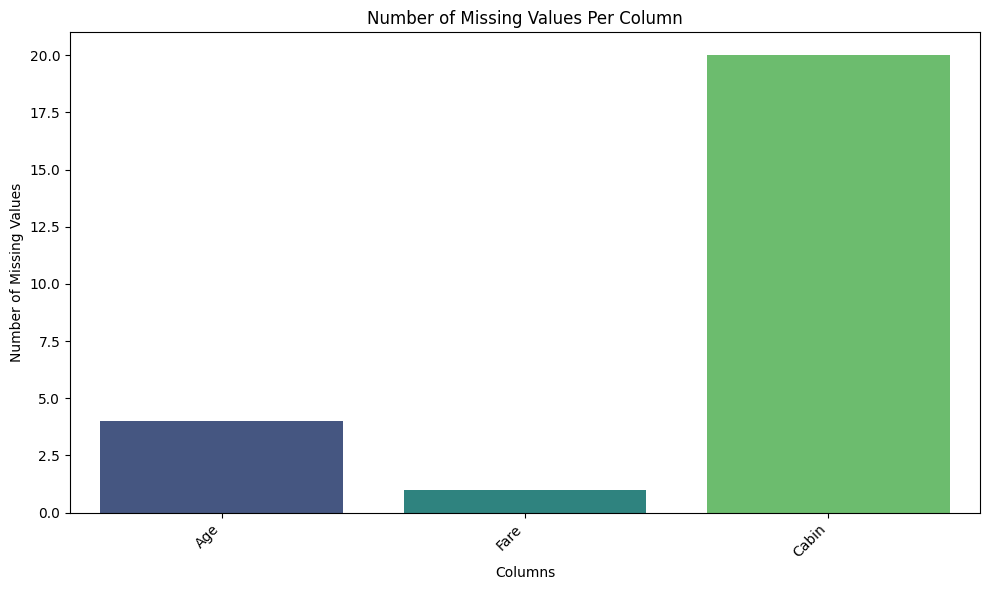

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of missing values per column
missing_data = inspector.df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    # Create a bar plot of missing values
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')
    plt.title('Number of Missing Values Per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

In [ ]:
# 4-E  Drop high-null columns that aren't useful for modelling
#      (interactive: leave blank and it will prompt; or pass a string directly)
inspector.delete_columns('Cabin, Ticket, Name')

✅ Successfully dropped columns: ['Cabin', 'Ticket', 'Name']


In [ ]:
# 4-F  Impute remaining missing values
#      Age  → median  (numeric, skewed)
#      Embarked → mode  (categorical)
inspector.handle_missing_values('Age, Fare', 'median')
inspector.handle_missing_values('Embarked', 'mode')

✅ Missing value resolution achieved via strategy: 'Age, Fare'.
✅ Missing value resolution achieved via strategy: 'Embarked'.


In [ ]:
# 4-G  Remove duplicate rows
inspector.remove_duplicates()

🧹 Removed 0 duplicate rows.


In [ ]:
# 4-H  Outlier detection & removal via IQR
inspector.handle_outliers(columns=['Age', 'Fare', 'SibSp', 'Parch'])

🚩 Outliers flagged successfully in the 'is_outlier' column.


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,is_outlier
0,1,0,3,male,NaN,1,0,7.2500,S,0
1,2,1,1,female,38.0,1,0,512.3292,C,1
2,3,1,3,female,26.0,0,0,NaN,S,0
3,4,1,1,female,35.0,1,0,53.1000,S,0
4,5,0,3,male,35.0,0,0,8.0500,S,0
5,6,0,3,male,NaN,0,0,8.4583,Q,0
6,7,0,1,male,54.0,0,0,51.8625,S,0
7,8,0,3,male,2.0,3,1,21.0750,S,1
8,9,1,3,female,27.0,0,2,11.1333,S,1
9,10,1,2,female,14.0,1,0,30.0708,C,0


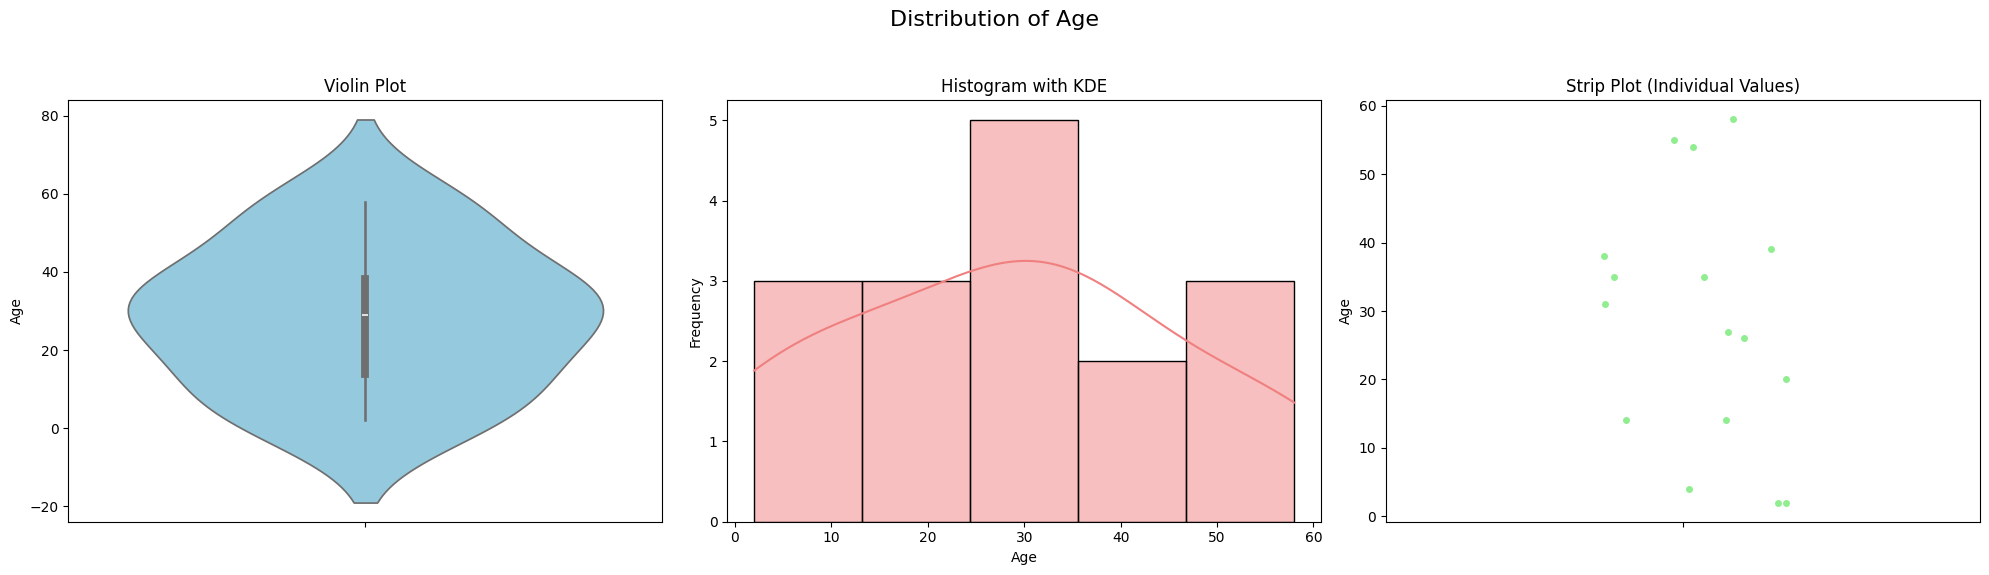

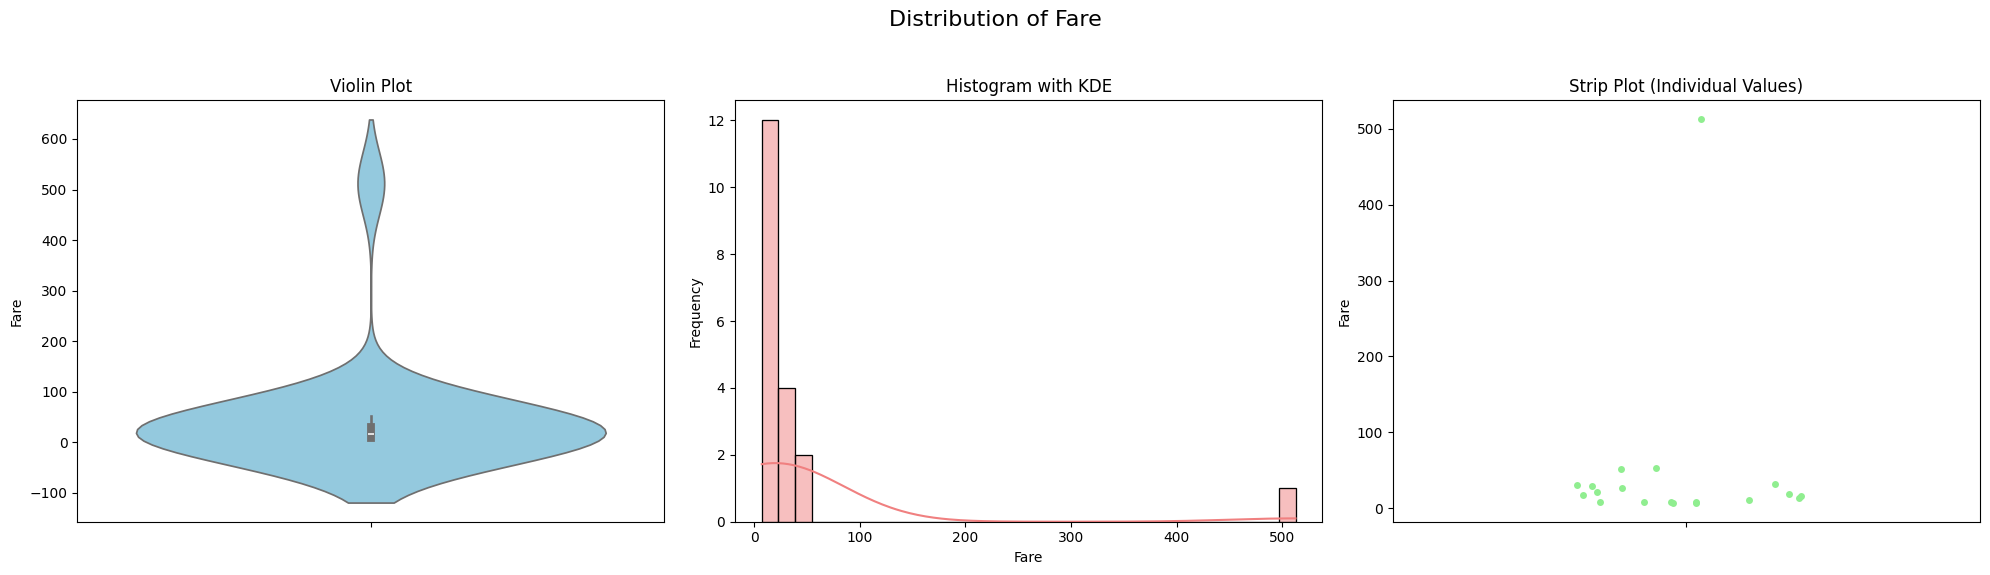

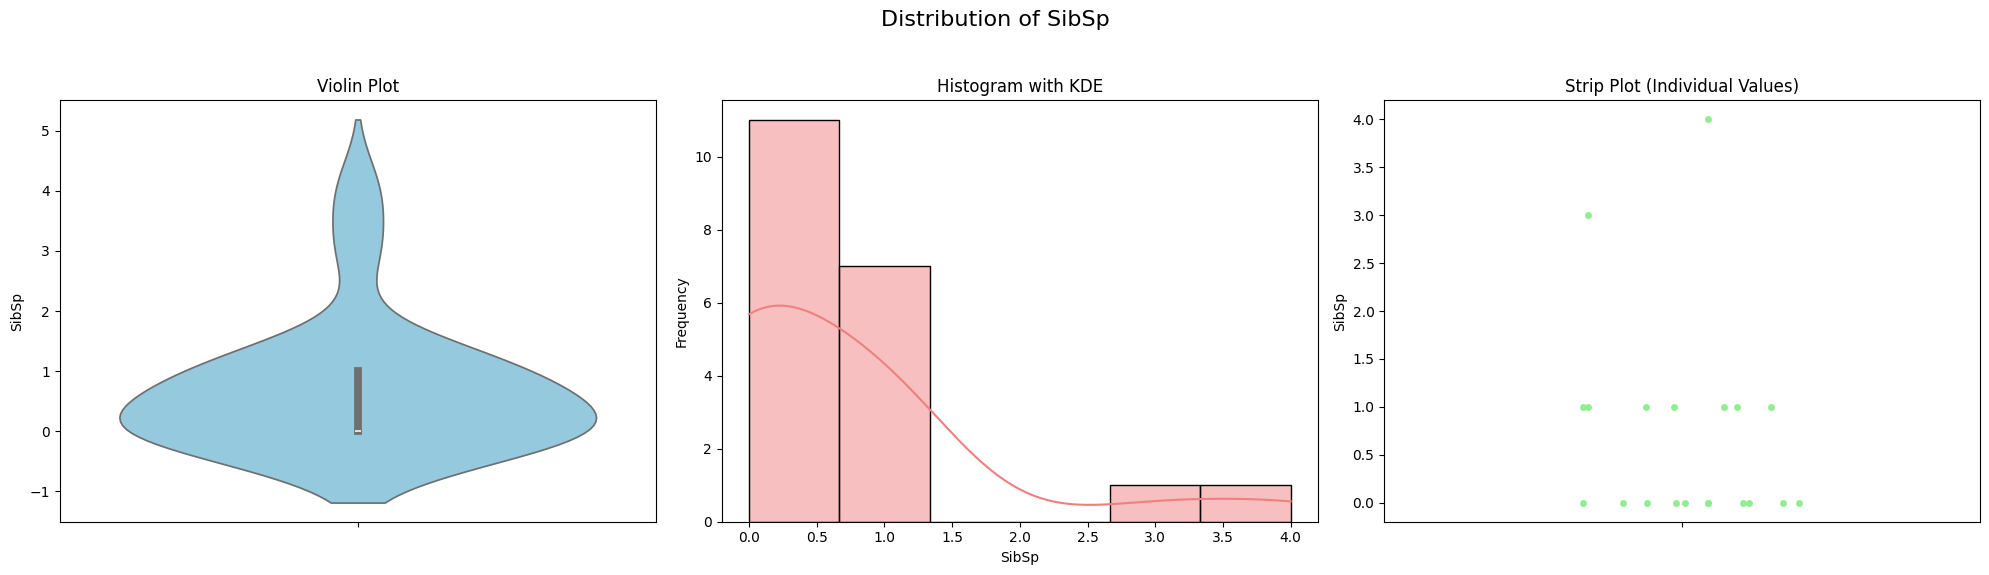

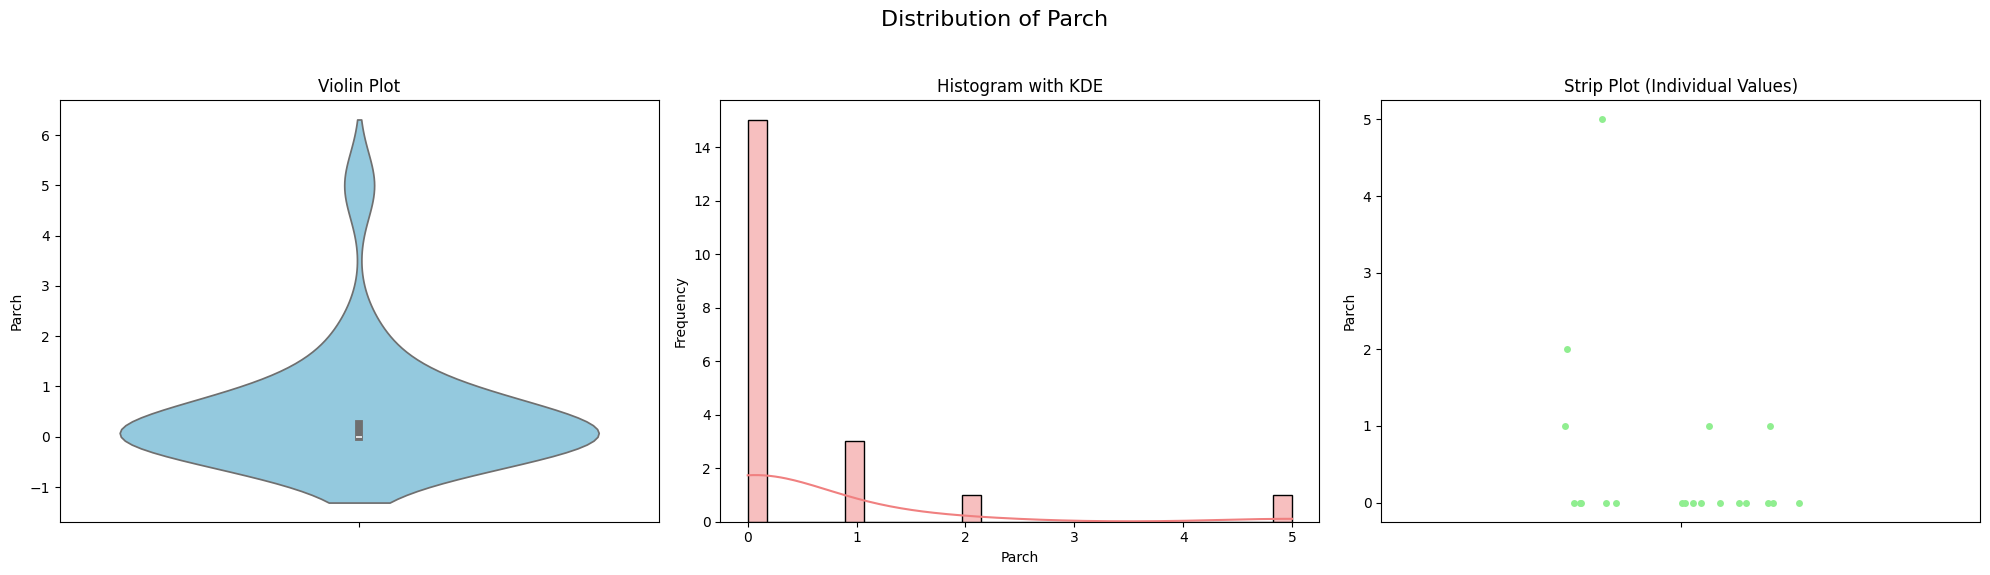

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5-A  3-panel numeric subplots: Violin | Scatter | Histogram
column_names = ['Age', 'Fare', 'SibSp', 'Parch']

for col in column_names:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Distribution of {col}', fontsize=16)

    # Violin Plot
    sns.violinplot(y=inspector.df[col], ax=axes[0], color='skyblue')
    axes[0].set_title('Violin Plot')
    axes[0].set_ylabel(col)

    # Histogram
    sns.histplot(inspector.df[col], kde=True, ax=axes[1], color='lightcoral')
    axes[1].set_title('Histogram with KDE')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frequency')

    # Strip Plot (as a scatter representation)
    sns.stripplot(y=inspector.df[col], ax=axes[2], color='lightgreen', jitter=0.2)
    axes[2].set_title('Strip Plot (Individual Values)')
    axes[2].set_ylabel(col)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

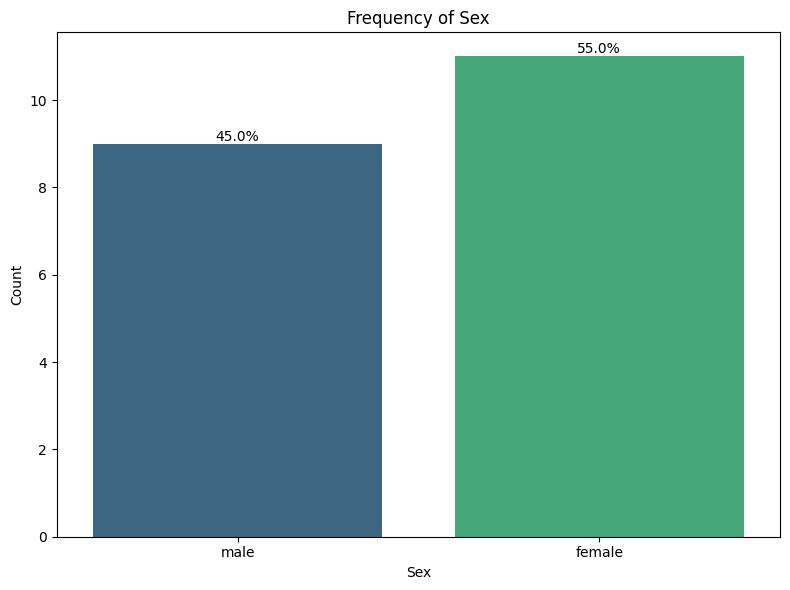

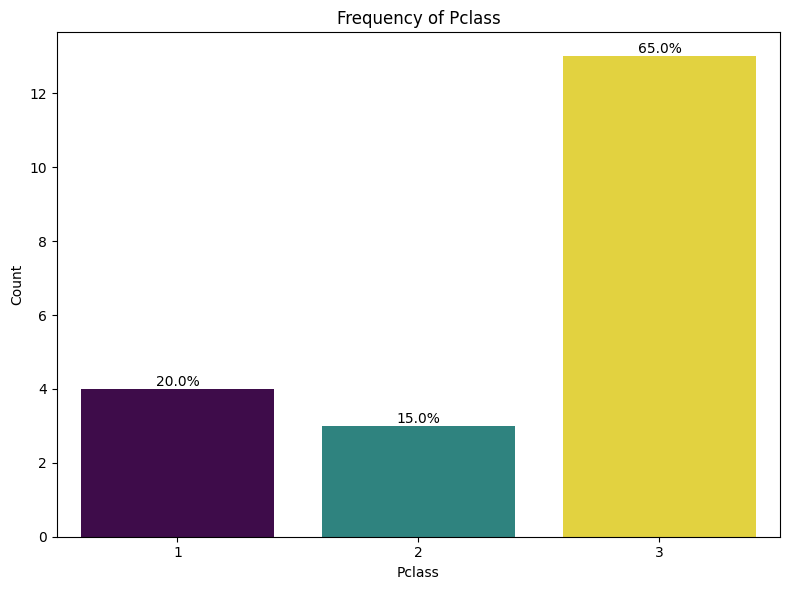

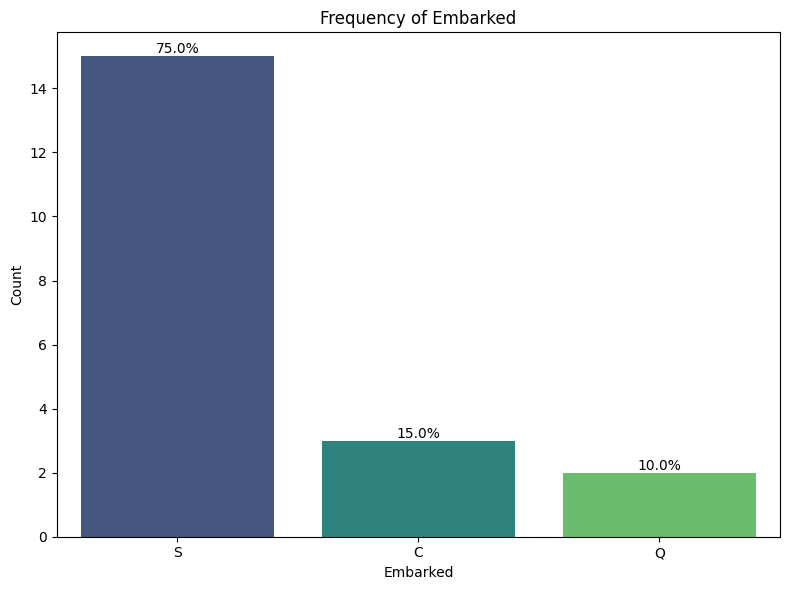

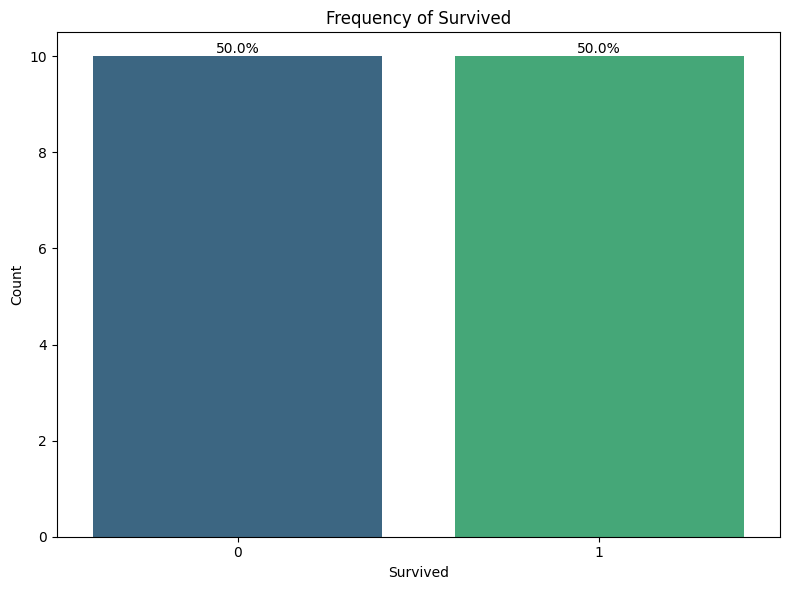

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5-B  Categorical frequency bar charts with % labels
column_names = ['Sex', 'Pclass', 'Embarked', 'Survived']

for col in column_names:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=col, data=inspector.df, palette='viridis', hue=col, legend=False)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    # Add percentage labels on top of bars
    total = len(inspector.df[col].dropna())
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

    plt.tight_layout()
    plt.show()

In [ ]:
# Num–Num: Scatter with OLS trendline
inspector.plot_relationship('Age', 'Fare')

In [ ]:
# Cat–Num: Box plot with individual points
inspector.plot_relationship('Pclass', 'Fare')

In [ ]:
# Cat–Num: Survival by Sex
inspector.plot_relationship('Sex', 'Survived')

In [ ]:
# Cat–Cat: Grouped bar — Embarked × Pclass
inspector.plot_relationship('Embarked', 'Pclass')

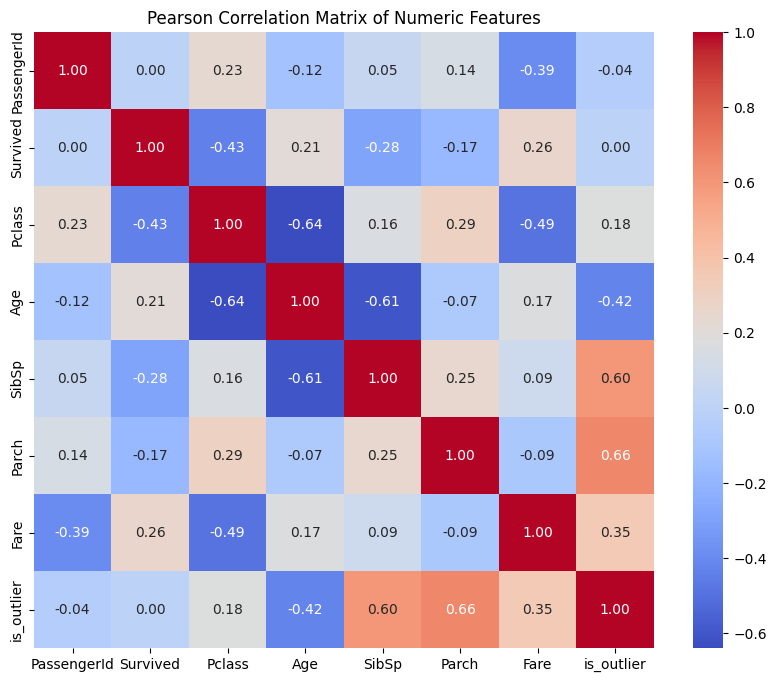

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7-A  Pearson correlation — numeric columns only
# Select only numerical columns for correlation calculation
numeric_cols = inspector.df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numeric_cols.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix of Numeric Features')
plt.show()

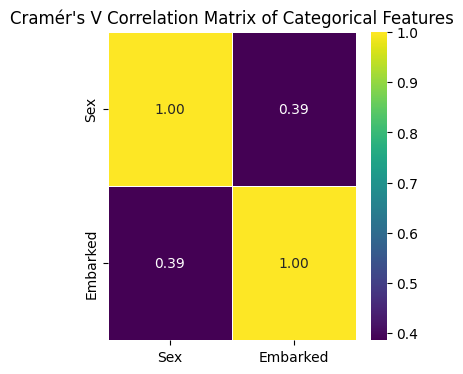

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Function to calculate Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))) if min((kcorr-1), (rcorr-1)) > 0 else 0

# 7-B  Cramér's V — categorical columns only
categorical_cols = inspector.df.select_dtypes(include='object').columns.tolist()

if not categorical_cols:
    print("No categorical columns found for Cramér's V calculation.")
else:
    num_categorical = len(categorical_cols)
    cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)

    for col1 in categorical_cols:
        for col2 in categorical_cols:
            if col1 == col2:
                cramers_v_matrix.loc[col1, col2] = 1.0
            else:
                v = cramers_v(inspector.df[col1], inspector.df[col2])
                cramers_v_matrix.loc[col1, col2] = v

    plt.figure(figsize=(num_categorical + 2, num_categorical + 2))
    sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
    plt.title("Cramér's V Correlation Matrix of Categorical Features")
    plt.show()

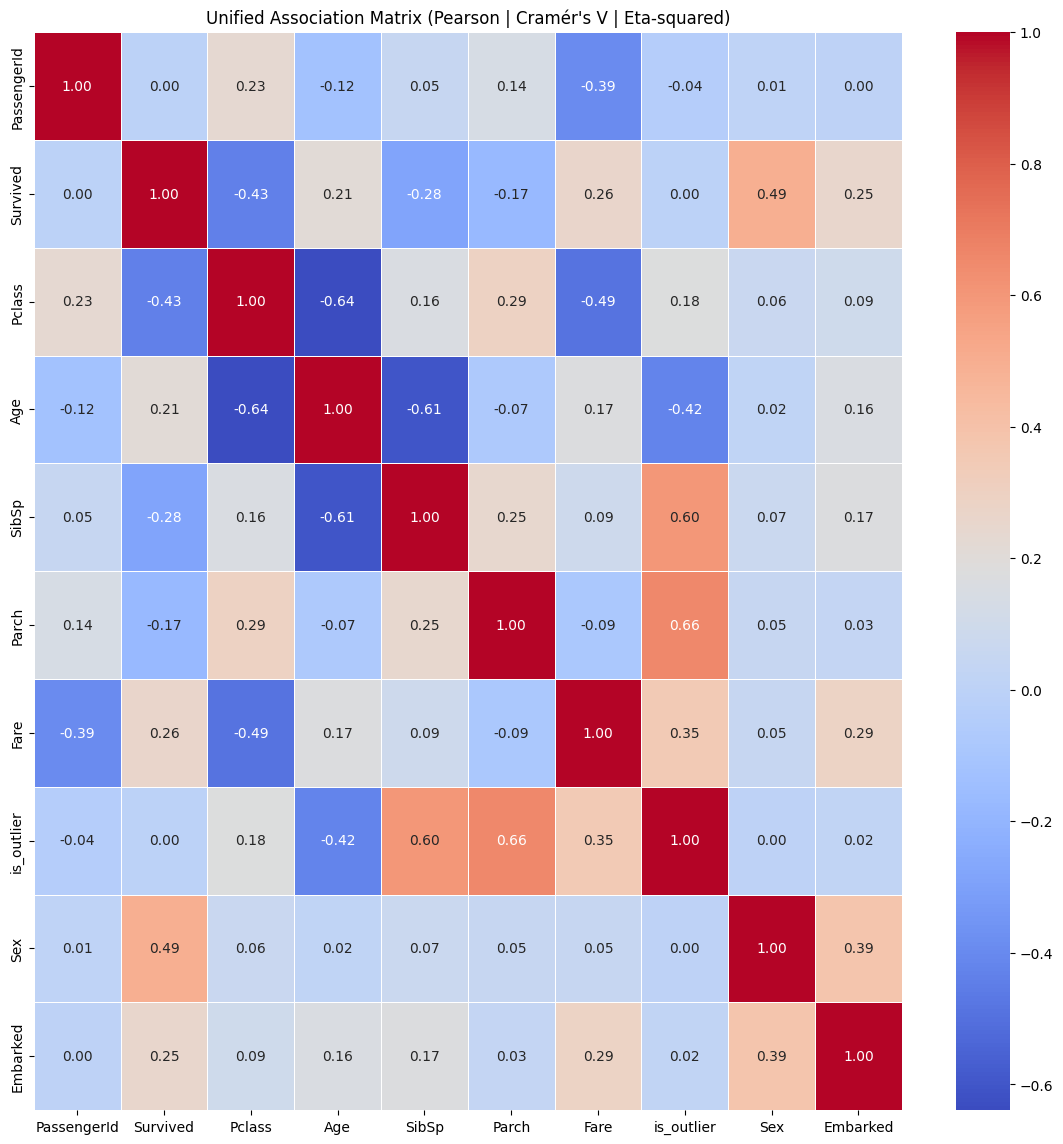

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Function to calculate Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Function to calculate Eta-squared (η²) for a categorical and a numerical variable.
def eta_squared(categorical_series, numerical_series):
    df_temp = pd.DataFrame({'categorical': categorical_series, 'numerical': numerical_series}).dropna()
    if df_temp.empty or df_temp['categorical'].nunique() <= 1:
        return 0.0

    grand_mean = df_temp['numerical'].mean()
    ss_total = ((df_temp['numerical'] - grand_mean)**2).sum()

    if ss_total == 0:
        return 0.0

    grouped_means = df_temp.groupby('categorical')['numerical'].mean()
    grouped_counts = df_temp.groupby('categorical')['numerical'].count()
    ss_between = (grouped_counts * ((grouped_means - grand_mean)**2)).sum()

    return ss_between / ss_total

# 7-C  Unified heatmap: Pearson | Cramér's V | Eta²
# Get numerical and categorical columns from the inspector's DataFrame
numeric_cols = inspector.df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = inspector.df.select_dtypes(include='object').columns.tolist()

all_cols = numeric_cols + categorical_cols
num_total_cols = len(all_cols)
correlation_matrix_unified = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for i in range(num_total_cols):
    for j in range(num_total_cols):
        col1_name = all_cols[i]
        col2_name = all_cols[j]

        series1 = inspector.df[col1_name]
        series2 = inspector.df[col2_name]

        if col1_name == col2_name:
            correlation_matrix_unified.loc[col1_name, col2_name] = 1.0
        else:
            is_num1 = col1_name in numeric_cols
            is_num2 = col2_name in numeric_cols
            is_cat1 = col1_name in categorical_cols
            is_cat2 = col2_name in categorical_cols

            if is_num1 and is_num2:
                # Pearson correlation
                corr = series1.corr(series2, method='pearson')
                correlation_matrix_unified.loc[col1_name, col2_name] = corr
            elif is_cat1 and is_cat2:
                # Cramér's V correlation
                v = cramers_v(series1, series2)
                correlation_matrix_unified.loc[col1_name, col2_name] = v
            elif (is_cat1 and is_num2):
                # Eta-squared (categorical vs numerical)
                eta = eta_squared(series1, series2)
                correlation_matrix_unified.loc[col1_name, col2_name] = eta
            elif (is_num1 and is_cat2):
                # Eta-squared (numerical vs categorical)
                eta = eta_squared(series2, series1) # Note: order matters for eta_squared
                correlation_matrix_unified.loc[col1_name, col2_name] = eta

plt.figure(figsize=(num_total_cols + 4, num_total_cols + 4))
sns.heatmap(correlation_matrix_unified, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Unified Association Matrix (Pearson | Cramér's V | Eta-squared)")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import pandas as pd
import numpy as np

# Get only numeric columns from the inspector's DataFrame
numeric_df = inspector.df.select_dtypes(include=np.number)

# Initialize scalers
minmax_scaler   = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler   = RobustScaler()

# 8-A  Numeric scaling — three strategies

# Min-Max Scaling
# Fit and transform the numeric data
norm_minmax_scaled_data = minmax_scaler.fit_transform(numeric_df)
# Convert back to DataFrame with original column names
norm_minmax   = pd.DataFrame(norm_minmax_scaled_data, columns=numeric_df.columns)

# Standard (Z-score) Scaling
# Fit and transform the numeric data
norm_standard_scaled_data = standard_scaler.fit_transform(numeric_df)
# Convert back to DataFrame with original column names
norm_standard = pd.DataFrame(norm_standard_scaled_data, columns=numeric_df.columns)

# Robust Scaling
# Fit and transform the numeric data
norm_robust_scaled_data = robust_scaler.fit_transform(numeric_df)
# Convert back to DataFrame with original column names
norm_robust   = pd.DataFrame(norm_robust_scaled_data, columns=numeric_df.columns)

print('Min-Max sample:')
display(norm_minmax.head())

print('\nStandard (Z-score) sample:')
display(norm_standard.head())

print('\nRobust (IQR) sample:')
display(norm_robust.head())

Min-Max sample:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,is_outlier
0,0.000000,0.0,1.0,NaN,0.25,0.0,0.000049,0.0
1,0.052632,1.0,0.0,0.642857,0.25,0.0,1.000000,1.0
2,0.105263,1.0,1.0,0.428571,0.00,0.0,NaN,0.0
3,0.157895,1.0,0.0,0.589286,0.25,0.0,0.090823,0.0
4,0.210526,0.0,1.0,0.589286,0.00,0.0,0.001633,0.0



Standard (Z-score) sample:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,is_outlier
0,-1.647509,-1.0,0.683507,NaN,0.284747,-0.430331,-0.351475,-0.654654
1,-1.474087,1.0,-1.801972,0.543400,0.284747,-0.430331,4.210494,1.527525
2,-1.300665,1.0,0.683507,-0.134086,-0.664411,-0.430331,NaN,-0.654654
3,-1.127243,1.0,-1.801972,0.374029,0.284747,-0.430331,0.062651,-0.654654
4,-0.953821,-1.0,0.683507,0.374029,-0.664411,-0.430331,-0.344249,-0.654654



Robust (IQR) sample:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,is_outlier
0,-1.000000,-0.5,0.0,NaN,1.0,0.0,-0.442753,0.0
1,-0.894737,0.5,-2.0,0.371134,1.0,0.0,23.221280,1.0
2,-0.789474,0.5,0.0,-0.123711,0.0,0.0,NaN,0.0
3,-0.684211,0.5,-2.0,0.247423,1.0,0.0,1.705417,0.0
4,-0.578947,-0.5,0.0,0.247423,0.0,0.0,-0.405271,0.0


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
import pandas as pd
import numpy as np

# Get only categorical columns from the inspector's DataFrame
categorical_df = inspector.df.select_dtypes(include='object').copy()

# 8-B  Categorical encoding — three strategies

# One-Hot Encoding
# Initialize OneHotEncoder with handle_unknown='ignore' for robust handling of unseen categories
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Fit and transform the categorical data
enc_onehot_encoded_data = onehot_encoder.fit_transform(categorical_df)
# Convert back to DataFrame with meaningful column names
enc_onehot = pd.DataFrame(enc_onehot_encoded_data, columns=onehot_encoder.get_feature_names_out(categorical_df.columns))

# Ordinal Encoding
# Initialize OrdinalEncoder with handle_unknown='use_encoded_value' and unknown_value=-1 for robust handling
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
# Fit and transform the categorical data
enc_ordinal_encoded_data = ordinal_encoder.fit_transform(categorical_df)
# Convert back to DataFrame with original column names
enc_ordinal = pd.DataFrame(enc_ordinal_encoded_data, columns=categorical_df.columns)

# Uniform (0-1 scaled) Encoding
# This will first Ordinal Encode, then apply MinMaxScaler
uniform_ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
uniform_minmax_scaler = MinMaxScaler()

# Fit and transform with OrdinalEncoder
enc_uniform_ordinal_data = uniform_ordinal_encoder.fit_transform(categorical_df)
# Apply MinMaxScaler to the ordinal encoded data
enc_uniform_scaled_data = uniform_minmax_scaler.fit_transform(enc_uniform_ordinal_data)
# Convert back to DataFrame with original column names
enc_uniform = pd.DataFrame(enc_uniform_scaled_data, columns=categorical_df.columns)


print('One-Hot sample:')
display(enc_onehot.head())

print('\nOrdinal sample:')
display(enc_ordinal.head())

print('\nUniform (0–1 scaled) sample:')
display(enc_uniform.head())

One-Hot sample:


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0



Ordinal sample:


,Sex,Embarked
0,1.0,2.0
1,0.0,0.0
2,0.0,2.0
3,0.0,2.0
4,1.0,2.0



Uniform (0–1 scaled) sample:


,Sex,Embarked
0,1.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,1.0
4,1.0,1.0


In [ ]:
# 8-C  Merged ML-ready DataFrame (robust numeric + ordinal categorical)

# Ensure the indices are aligned for concatenation
# The dataframes norm_robust and enc_ordinal are already created in previous cells.
# They should have the same number of rows and aligned indices if created from the same inspector.df

# Concatenate the robustly scaled numeric data and ordinal encoded categorical data
final_df = pd.concat([norm_robust, enc_ordinal], axis=1)

display(final_df.head())
print('Shape:', final_df.shape)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,is_outlier,Sex,Embarked
0,-1.000000,-0.5,0.0,NaN,1.0,0.0,-0.442753,0.0,1.0,2.0
1,-0.894737,0.5,-2.0,0.371134,1.0,0.0,23.221280,1.0,0.0,0.0
2,-0.789474,0.5,0.0,-0.123711,0.0,0.0,NaN,0.0,0.0,2.0
3,-0.684211,0.5,-2.0,0.247423,1.0,0.0,1.705417,0.0,0.0,2.0
4,-0.578947,-0.5,0.0,0.247423,0.0,0.0,-0.405271,0.0,1.0,2.0


Shape: (20, 10)


In [ ]:
# Instantiate the standalone plotter
PLT = PlottingMethods()

In [ ]:
from IPython.display import display

# 9-A  List all available chart methods
# The get_methods_info() method was not found.
# We will use dir() to inspect available attributes and methods.
response = dir(PLT)
display(response)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'generate_bar_chart',
 'generate_histogram',
 'generate_pie_chart']

/tmp/ipykernel_3703/3431585129.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




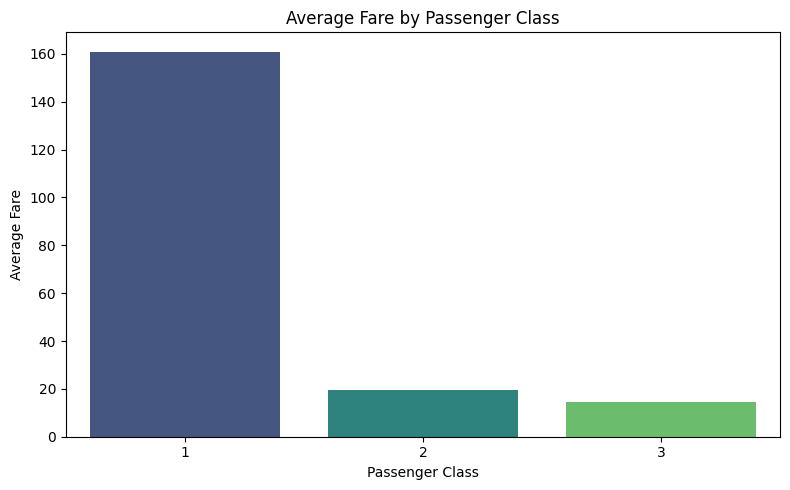

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9-B Bar chart: average Fare per Passenger Class
# The custom generate_bar_chart method failed with TypeError for keyword arguments.
# Using seaborn and matplotlib for reliable plotting.

# Calculate the average fare per passenger class
average_fare_per_pclass = inspector.df.groupby('Pclass')['Fare'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Fare', data=average_fare_per_pclass, palette='viridis')
plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

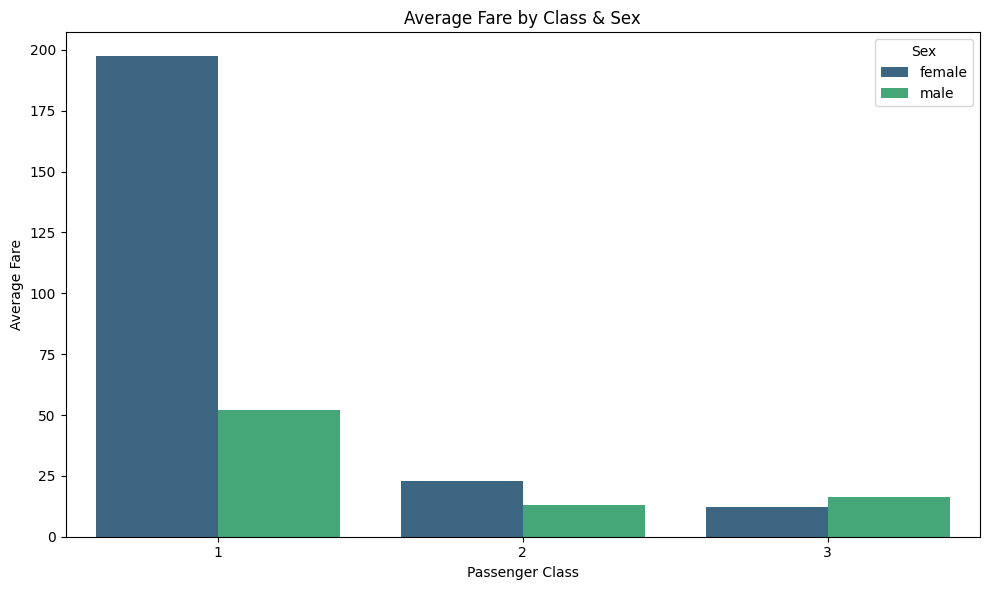

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9-C Grouped bar chart: Fare by Pclass, coloured by Sex
# The custom plot_bar_chart method failed with AttributeError.
# Using seaborn and matplotlib for reliable plotting.

plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Fare', hue='Sex', data=inspector.df, palette='viridis', errorbar=None)
plt.title('Average Fare by Class & Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.tight_layout()
plt.show()

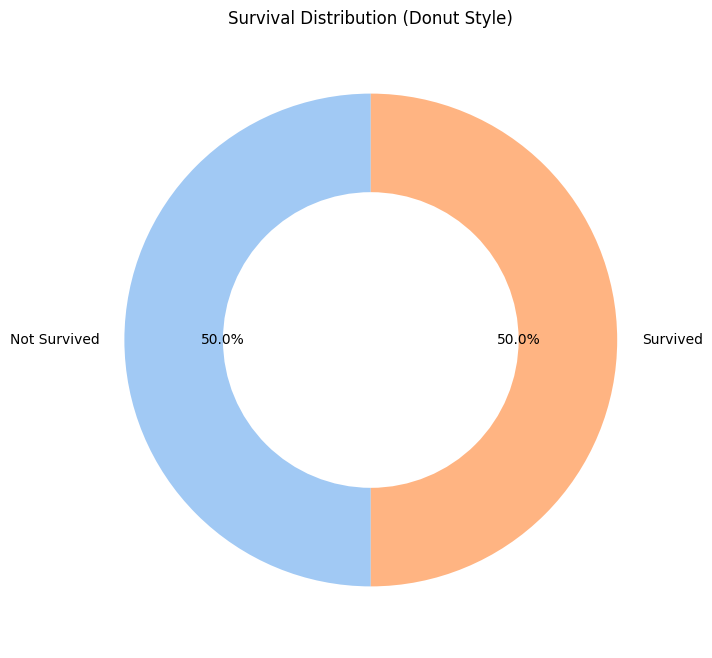

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9-D  Pie chart: survival split (donut style)
# The custom plot_pie_chart method failed with AttributeError.
# Using seaborn and matplotlib for reliable plotting.

# Calculate counts for 'Survived' column
survival_counts = inspector.df['Survived'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(survival_counts,
        labels=['Not Survived', 'Survived'], # Assuming 0=Not Survived, 1=Survived
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.4), # For donut style
        colors=sns.color_palette('pastel')[0:2])
plt.title('Survival Distribution (Donut Style)')
plt.ylabel('') # Hide the default 'y' label
plt.show()

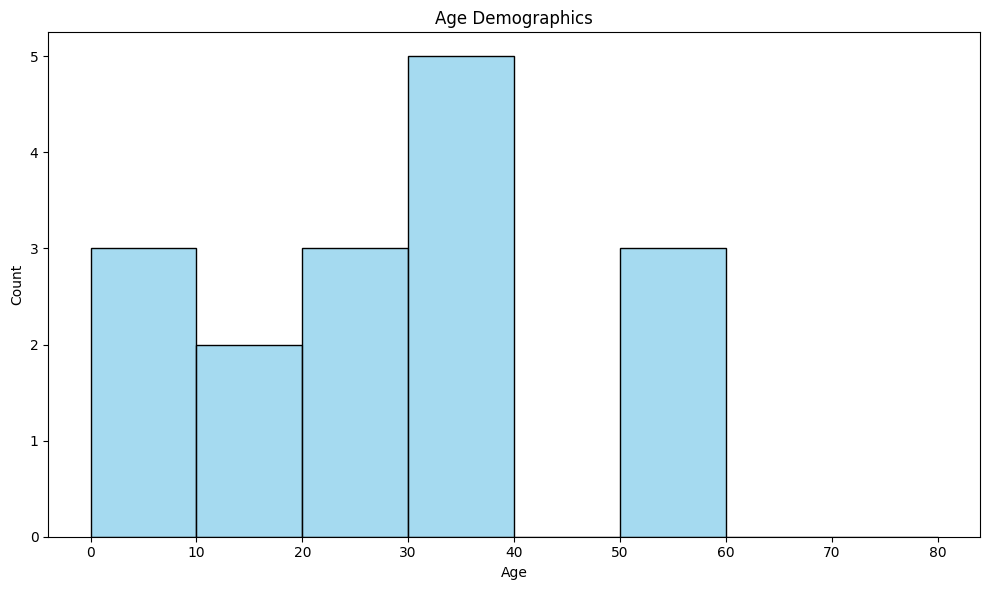

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9-E  Histogram: Age distribution with custom bins
# The custom plot_histogram method failed with AttributeError.
# Using seaborn and matplotlib for reliable plotting.

plt.figure(figsize=(10, 6))
sns.histplot(inspector.df['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], kde=False, color='skyblue', edgecolor='black')
plt.title('Age Demographics')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
plt.tight_layout()
plt.show()

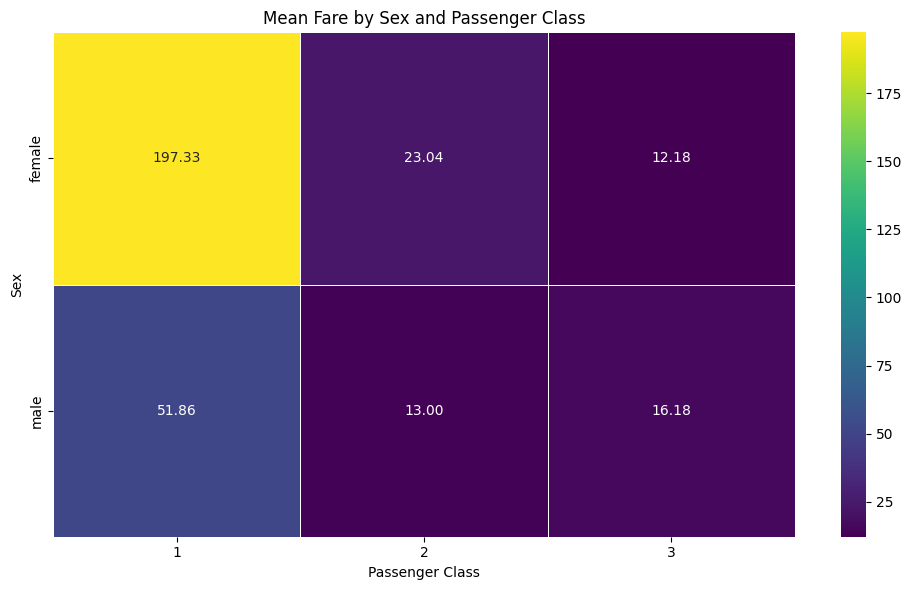

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 9-F  Pivot heatmap: mean Fare by Sex × Pclass
# The custom plot_heat_map method failed with AttributeError.
# Using pandas, seaborn and matplotlib for reliable plotting.

# Create a pivot table for mean Fare by Sex and Pclass
pivot_table = inspector.df.pivot_table(values='Fare', index='Sex', columns='Pclass', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Mean Fare by Sex and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Sex')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# 9-G  Sankey diagram: Embarked → Pclass flow (weighted by Fare)
# The custom plot_sankey_diagram method failed with AttributeError.
# Using plotly.graph_objects for reliable plotting.

# Prepare data for Sankey diagram
# Drop rows with NaN in 'Embarked' or 'Pclass' or 'Fare' if any, which could disrupt grouping
sankey_data = inspector.df.dropna(subset=['Embarked', 'Pclass', 'Fare']).groupby(['Embarked', 'Pclass'])['Fare'].sum().reset_index()

# Create unique labels for nodes (Embarked and Pclass)
labels = list(sankey_data['Embarked'].unique()) + list(sankey_data['Pclass'].unique().astype(str))

# Create mappings from original values to node indices
label_map = {label: i for i, label in enumerate(labels)}

# Prepare source, target, and value lists for Plotly Sankey
source = [label_map[s] for s in sankey_data['Embarked']]
target = [label_map[str(t)] for t in sankey_data['Pclass']]
value  = sankey_data['Fare'].tolist()

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color="blue"
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(title_text='Embarked \u2192 Pclass Flow (Weighted by Fare)', font_size=10)
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 9-H  Sunburst chart: Sex → Pclass hierarchy, sized by Fare
# The custom plot_simple_sunburst_graph method failed with AttributeError.
# Using plotly.express for reliable plotting.

# Ensure data is clean for plotting (e.g., no NaN in relevant columns)
sunburst_df = inspector.df.dropna(subset=['Sex', 'Pclass', 'Fare']).copy()

# Convert Pclass to string for categorical path in Plotly Express
sunburst_df['Pclass'] = sunburst_df['Pclass'].astype(str)

fig = px.sunburst(sunburst_df,
                  path=['Sex', 'Pclass'],
                  values='Fare',
                  title='Fare Hierarchy: Sex \u2192 Passenger Class',
                  color_discrete_sequence=px.colors.qualitative.Pastel)

fig.show()